In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

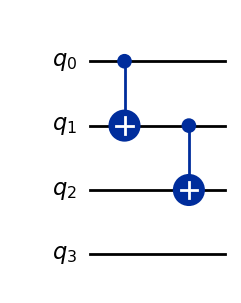

In [13]:
oracle = QuantumCircuit(4)

oracle.cx(0, 1)
oracle.cx(1, 2)

display(oracle.draw("mpl"))

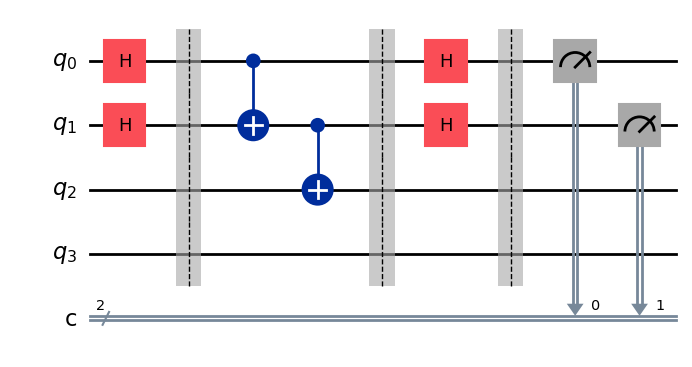

In [14]:
simon_circuit = QuantumCircuit(4, 2)

simon_circuit.h([0, 1])
simon_circuit.barrier()

simon_circuit.compose(oracle, inplace=True)
simon_circuit.barrier()

simon_circuit.h([0, 1])
simon_circuit.barrier()

simon_circuit.measure([0, 1], [0, 1])

display(simon_circuit.draw("mpl"))

In [15]:
result = AerSimulator().run(simon_circuit, shots=1000, memory=True).result()
counts = result.get_counts()

print(f"Recorded states: {counts}")

Recorded states: {'10': 503, '00': 497}
